# CNN capacity and data scaling

This notebook is centered around one question: **how much CNN capacity is useful for a given amount of training data?** The experiment varies training-set size $N$ and a width-scaled CNN family whose actual trainable parameter count is $P$. The fixed `validate` fold is used for early stopping and for the small learning-rate selection inside each $(N,P)$ cell. The test fold is never loaded here.

## Workflow

1. **Memorization sanity check** on one small stratified mini-dataset.
2. **Joint $N \times P$ matrix** using nested stratified subsets and a small inner learning-rate sweep.
3. **Scaling analysis** using tune cross-entropy and the train/tune gap.
4. **Empirical scaling and compute efficiency** using $P_\epsilon(N)$, a descriptive loss surface and the wall-clock frontier.
5. **Optimizer-only tuning and export** for the fixed width-8 model, followed by multi-seed confirmation and a reload-verified candidate for Notebook 03.

In [69]:
from dataclasses import asdict
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from pytorch_timecourse_classification.artifacts import artifact_root
from pytorch_timecourse_classification.data import load_training_folds
from pytorch_timecourse_classification.experiments import (
    create_model, fit_model, save_and_verify_experiment,
    trainable_parameter_count,
)
from pytorch_timecourse_classification.models.cnn import CNNClassifier, scaled_cnn_config
from pytorch_timecourse_classification.scaling import (
    ScalingConfig, compute_efficiency_frontier, fit_scaling_surface,
    near_optimal_parameter_count, run_memorization_check,
    run_scaling_grid, select_best_learning_rate,
)
from pytorch_timecourse_classification.tracking import MLflowTrackingConfig
from pytorch_timecourse_classification.training import TrainingConfig
from pytorch_timecourse_classification.tuning import (
    AblationSpec, OptunaScanConfig, optuna_parameter_importances,
    run_ablations, run_optuna_scan, save_ablation_study,
    suggest_extended_cnn_training_config, summarize_ablations,
)

In [70]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_fold, tune_fold, preprocessor = load_training_folds()
print("device:", device)
print("train:", tuple(train_fold.features.shape))
print("tune:", tuple(tune_fold.features.shape))
print("classes:", preprocessor.class_names)

device: cuda
train: (2790, 1, 289)
tune: (349, 1, 289)
classes: ('0pM', '1pM', '2.5pM', '5pM', '25pM', '100pM')


## Fixed CNN family

Only convolutional channel width and the hidden width of the classification head scale. Depth, kernels `(9, 7, 5)`, dilation, pooling and the target task remain fixed, so $P$ is a cleaner capacity axis than changing depth.

In [71]:
BASE_MODEL_CONFIG = {
    "kernel_sizes": (9, 7, 5),
    "dilations": (1, 1, 1),
    "pool_size": 2,
    "dropout": 0.2,
    "residual": False,
}
WIDTH_MULTIPLIERS = (0.25, 0.5, 1.0, 2.0, 4.0, 8.0)

rows = []
for width in WIDTH_MULTIPLIERS:
    cfg = scaled_cnn_config(width)
    model = CNNClassifier(
        input_length=train_fold.features.shape[-1],
        num_classes=len(preprocessor.class_names),
        **BASE_MODEL_CONFIG, **cfg,
    )
    rows.append({
        "width_multiplier": width,
        "channels": cfg["channels"],
        "hidden_dim": cfg["hidden_dim"],
        "parameter_count": trainable_parameter_count(model),
    })
display(pd.DataFrame(rows))

,width_multiplier,channels,hidden_dim,parameter_count
0,0.25,"(8, 16, 32)",16,4326
1,0.50,"(16, 32, 64)",32,16582
2,1.00,"(32, 64, 128)",64,64902
3,2.00,"(64, 128, 256)",128,256774
4,4.00,"(128, 256, 512)",256,1021446
5,8.00,"(256, 512, 1024)",512,4074502


## 1. Memorization sanity check

This diagnostic separates basic trainability from generalization. A small **stratified** sample is trained without dropout, weight decay, scheduler or gradient clipping. The fixed `validate` fold is monitored separately but does not affect the memorization pass/fail decision.

In [72]:
memorization = run_memorization_check(
    model_type=CNNClassifier,
    training_fold=train_fold,
    validation_fold=tune_fold,
    preprocessor=preprocessor,
    base_model_config=BASE_MODEL_CONFIG,
    width_multiplier=1.0,
    sample_count=32,
    epochs=1000,
    learning_rate=3e-3,
    device=device,
)
memorization_summary = asdict(memorization)
for curve_name in ("loss_curve", "accuracy_curve", "validation_loss_curve", "validation_accuracy_curve"):
    memorization_summary.pop(curve_name)
display(pd.Series(memorization_summary))
if not memorization.passed:
    raise RuntimeError("Memorization check failed; the model did not fit the 32-example subset.")

model_config: {'input_length': 289, 'num_classes': 6, 'channels': (32, 64, 128), 'kernel_sizes': (9, 7, 5), 'dilations': (1, 1, 1), 'pool_size': 2, 'hidden_dim': 64, 'dropout': 0.0, 'residual': False}
trainable parameters: 64,902
training_config: TrainingConfig(epochs=1000, batch_size=32, learning_rate=0.003, weight_decay=0.0, scheduler_step_size=10, learning_rate_decay=0.8, scheduler_strategy='none', warmup_epochs=0, warmup_start_factor=0.1, minimum_learning_rate=1e-06, patience=1000, report_every=200, random_seed=42, class_balance_strategy='none', gradient_clip_norm=None)
epoch   1: train loss 1.83064, validation loss 1.78198, train accuracy 12.5%, validation accuracy 22.1%
epoch 200: train loss 0.00047, validation loss 3.64232, train accuracy 100.0%, validation accuracy 42.1%
epoch 400: train loss 0.00014, validation loss 3.94794, train accuracy 100.0%, validation accuracy 42.7%
epoch 600: train loss 0.00006, validation loss 4.10720, train accuracy 100.0%, validation accuracy 41.5%


n_samples                      32
parameter_count             64902
initial_loss             1.801872
final_loss               0.000024
final_accuracy                1.0
best_epoch                   1000
validation_best_epoch          13
passed                       True
dtype: object

### Joint train/validation trajectories

Cross-entropy is the loss function in this experiment; a separate `loss` and `cross-entropy` plot would therefore duplicate the same values. The plots below show **cross-entropy loss** and **accuracy**, each with training and held-out validation on the same axes. Dashed horizontal lines mark random-chance performance, and the dashed vertical lines mark the epoch with minimum validation loss.

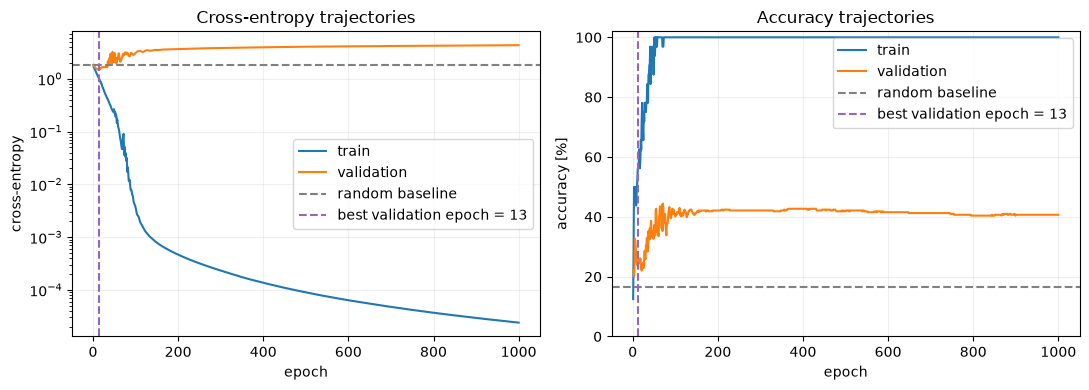

In [73]:
memorization_epochs = np.arange(1, len(memorization.loss_curve) + 1)
validation_epochs = np.arange(1, len(memorization.validation_loss_curve) + 1)
chance_loss = np.log(len(preprocessor.class_names))
chance_accuracy = 100 / len(preprocessor.class_names)
figure, (loss_axis, accuracy_axis) = plt.subplots(1, 2, figsize=(11, 4))

loss_axis.plot(memorization_epochs, memorization.loss_curve, label="train")
loss_axis.plot(validation_epochs, memorization.validation_loss_curve, label="validation")
loss_axis.axhline(chance_loss, color="0.5", linestyle="--", label="random baseline")
loss_axis.axvline(
    memorization.validation_best_epoch, color="tab:purple", linestyle="--",
    label=f"best validation epoch = {memorization.validation_best_epoch}",
)
loss_axis.set_yscale("log")
loss_axis.set(title="Cross-entropy trajectories", xlabel="epoch", ylabel="cross-entropy")
loss_axis.grid(alpha=0.2)
loss_axis.legend()

accuracy_axis.plot(memorization_epochs, 100 * np.asarray(memorization.accuracy_curve), label="train")
accuracy_axis.plot(validation_epochs, 100 * np.asarray(memorization.validation_accuracy_curve), label="validation")
accuracy_axis.axhline(chance_accuracy, color="0.5", linestyle="--", label="random baseline")
accuracy_axis.axvline(
    memorization.validation_best_epoch, color="tab:purple", linestyle="--",
    label=f"best validation epoch = {memorization.validation_best_epoch}",
)
accuracy_axis.set(title="Accuracy trajectories", xlabel="epoch", ylabel="accuracy [%]", ylim=(0, 102))
accuracy_axis.grid(alpha=0.2)
accuracy_axis.legend()

figure.tight_layout()

#### Interpretation

The joint view makes the generalization gap explicit: after the validation optimum at epoch 13, training cross-entropy continues downward by several orders of magnitude while validation cross-entropy increases. At the final epoch, training and validation accuracy differ by 59.3 percentage points (100.0% versus 40.7%). This is the canonical overfitting pattern and confirms that the memorization test is a trainability check rather than evidence for predictive performance.

## 2. Joint $N \times P$ matrix

Training subsets are nested and stratified. For each $(N,P)$ cell, three learning rates are tried from the same model seed and the minimum validation cross-entropy selects the learning rate. The scheduler is disabled so the inner sweep remains interpretable rather than becoming another broad tuning exercise.

In [46]:
SCALING_CONFIG = ScalingConfig(
    data_fractions=(0.0625, 0.125, 0.25, 0.5, 1.0),
    width_multipliers=WIDTH_MULTIPLIERS,
    learning_rates=(1e-4, 3e-4, 1e-3),
    subset_seed=42,
    model_seed=42,
)
BASE_TRAINING_CONFIG = TrainingConfig(
    epochs=200, batch_size=128, learning_rate=1e-3,
    weight_decay=1e-4, scheduler_strategy="none",
    patience=5, report_every=20, random_seed=42,
    class_balance_strategy="none", gradient_clip_norm=1.0,
)
print(SCALING_CONFIG)
print(BASE_TRAINING_CONFIG)

ScalingConfig(data_fractions=(0.0625, 0.125, 0.25, 0.5, 1.0), width_multipliers=(0.25, 0.5, 1.0, 2.0, 4.0), learning_rates=(0.0001, 0.0003, 0.001), subset_seed=42, model_seed=42)
TrainingConfig(epochs=200, batch_size=128, learning_rate=0.001, weight_decay=0.0001, scheduler_step_size=10, learning_rate_decay=0.8, scheduler_strategy='none', warmup_epochs=0, warmup_start_factor=0.1, minimum_learning_rate=1e-06, patience=5, report_every=20, random_seed=42, class_balance_strategy='none', gradient_clip_norm=1.0)


In [47]:
scaling_dir = artifact_root() / "cnn_scaling"
scaling_dir.mkdir(parents=True, exist_ok=True)
runs_path = scaling_dir / "np_lr_grid.csv"
trajectory_columns = {
    "training_loss_curve", "tune_loss_curve",
    "training_accuracy_curve", "tune_accuracy_curve",
    "batch_size", "max_epochs", "patience", "scheduler_strategy",
}
RECOMPUTE = False

cached_runs = pd.read_csv(runs_path) if runs_path.exists() else None
cache_has_trajectories = (
    cached_runs is not None and trajectory_columns.issubset(cached_runs.columns)
)
expected_grid_keys = {
    (float(fraction), float(width), float(learning_rate))
    for fraction in SCALING_CONFIG.data_fractions
    for width in SCALING_CONFIG.width_multipliers
    for learning_rate in SCALING_CONFIG.learning_rates
}
cached_grid_keys = (
    set(zip(
        cached_runs["data_fraction"].astype(float),
        cached_runs["width_multiplier"].astype(float),
        cached_runs["learning_rate"].astype(float),
    ))
    if cached_runs is not None and {"data_fraction", "width_multiplier", "learning_rate"}.issubset(cached_runs.columns)
    else set()
)
cache_matches_grid = (
    len(cached_runs) == len(expected_grid_keys)
    and cached_grid_keys == expected_grid_keys
) if cached_runs is not None else False
needs_recompute = (
    RECOMPUTE or cached_runs is None
    or not cache_has_trajectories or not cache_matches_grid
)

if needs_recompute:
    if cached_runs is not None:
        print("cached grid does not match the requested grid; computing the complete grid")
    runs = run_scaling_grid(
        model_type=CNNClassifier, training_fold=train_fold,
        tuning_fold=tune_fold, preprocessor=preprocessor,
        base_model_config=BASE_MODEL_CONFIG,
        base_training_config=BASE_TRAINING_CONFIG,
        scaling_config=SCALING_CONFIG, device=device, verbose=True,
    )
    runs.to_csv(runs_path, index=False)
else:
    runs = cached_runs
    print("loaded cached grid:", runs_path)
print(f"runs={len(runs)}, failed={int(runs['failed'].sum())}")

loaded cached grid: /home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/cnn_scaling/np_lr_grid.csv
runs=90, failed=0


In [48]:
selected_runs = select_best_learning_rate(runs)
selected_runs.to_csv(scaling_dir / "np_selected_lr.csv", index=False)
display(selected_runs[[
    "n_samples", "parameter_count", "width_multiplier",
    "learning_rate", "training_loss", "tune_loss",
    "training_macro_f1", "tune_macro_f1",
    "best_epoch", "duration_seconds",
]])

,n_samples,parameter_count,width_multiplier,learning_rate,training_loss,tune_loss,training_macro_f1,tune_macro_f1,best_epoch,duration_seconds
0,174,4326,0.25,0.0010,1.263114,1.282960,0.435029,0.404744,61,0.875709
1,174,16582,0.50,0.0010,1.122751,1.154805,0.479590,0.457714,55,0.931434
2,174,64902,1.00,0.0010,1.034975,1.090026,0.491997,0.486929,40,0.672832
3,174,256774,2.00,0.0003,0.964285,1.060493,0.577450,0.482866,72,1.334585
4,174,1021446,4.00,0.0003,0.924179,1.063197,0.585935,0.486739,36,1.256626
5,174,4074502,8.00,0.0001,0.916612,1.085759,0.613543,0.500126,41,3.460190
6,350,4326,0.25,0.0010,1.212099,1.226258,0.413220,0.371614,44,0.914408
7,350,16582,0.50,0.0010,1.133421,1.189215,0.435600,0.477624,34,0.702331
8,350,64902,1.00,0.0010,0.926785,1.015640,0.542105,0.499940,56,1.074998
9,350,256774,2.00,0.0003,0.917684,1.027630,0.569722,0.546669,57,1.474276


### Optimization budget by data size

An epoch is not a comparable unit when $N$ changes: the number of optimizer updates per epoch is $\lceil N / B \rceil$. The table converts epochs and patience into approximate update counts.

In [49]:
scaling_dir = artifact_root() / "cnn_scaling"
selected_runs_path = scaling_dir / "np_selected_lr.csv"
if "selected_runs" not in globals():
    if not selected_runs_path.exists():
        raise FileNotFoundError(
            f"Selected-run results are unavailable at {selected_runs_path}."
        )
    selected_runs = pd.read_csv(selected_runs_path)

required_run_metadata = {"batch_size", "max_epochs", "patience", "scheduler_strategy"}
missing_run_metadata = required_run_metadata.difference(selected_runs.columns)
if missing_run_metadata:
    raise RuntimeError(
        "The selected-run cache predates training-metadata logging "
        f"(missing: {sorted(missing_run_metadata)}); the optimization budget cannot be reconstructed."
    )

optimization_runs = selected_runs.assign(
    batches_per_epoch=np.ceil(selected_runs["n_samples"] / selected_runs["batch_size"]).astype(int),
)
optimization_runs["optimizer_steps_run"] = (
    optimization_runs["batches_per_epoch"] * optimization_runs["epochs_run"]
)
optimization_runs["patience_optimizer_steps"] = (
    optimization_runs["batches_per_epoch"] * optimization_runs["patience"]
)
optimization_budget = optimization_runs.groupby("n_samples", as_index=False).agg(
    batches_per_epoch=("batches_per_epoch", "first"),
    min_epochs_run=("epochs_run", "min"),
    median_epochs_run=("epochs_run", "median"),
    max_epochs_run=("epochs_run", "max"),
    median_optimizer_steps=("optimizer_steps_run", "median"),
    patience_optimizer_steps=("patience_optimizer_steps", "first"),
)
display(optimization_budget)

,n_samples,batches_per_epoch,min_epochs_run,median_epochs_run,max_epochs_run,median_optimizer_steps,patience_optimizer_steps
0,174,2,41,53.0,77,106.0,10
1,350,3,34,44.0,62,132.0,15
2,697,6,24,30.0,41,180.0,30
3,1394,11,31,39.0,76,429.0,55
4,2790,22,19,26.5,28,583.0,110


#### Interpretation

With batch size 128, one epoch represents only 2 optimizer updates at $N=174$ but 22 updates at $N=2{,}790$. Across the six widths, the median completed budget consequently rises from 106 to 583 updates, again a factor of 5.5. All 30 selected runs stop between epochs 19 and 77, five epochs after their best validation checkpoint and well before the ceiling of 200 epochs. Thus `scheduler_strategy="none"` denotes a constant learning rate, whereas `patience=5` remains active as the early-stopping rule.

### Selected-run training trajectories

Each panel fixes the training-set size $N$. Color denotes model width; solid lines are training and dashed lines are held-out validation. Cross-entropy is the loss used for optimization, so the two requested quantities are shown as **cross-entropy loss** and **accuracy** rather than duplicating loss under two names.

In [50]:
def decode_curve(value):
    if isinstance(value, str):
        return np.asarray(json.loads(value), dtype=float)
    return np.asarray(value, dtype=float)

n_values = sorted(selected_runs["n_samples"].unique())
width_values = sorted(selected_runs["width_multiplier"].unique())
high_contrast_colors = ("#0072B2", "#D55E00", "#009E73", "#CC79A7", "#000000", "#E69F00")
width_colors = {
    width: high_contrast_colors[index % len(high_contrast_colors)]
    for index, width in enumerate(width_values)
}

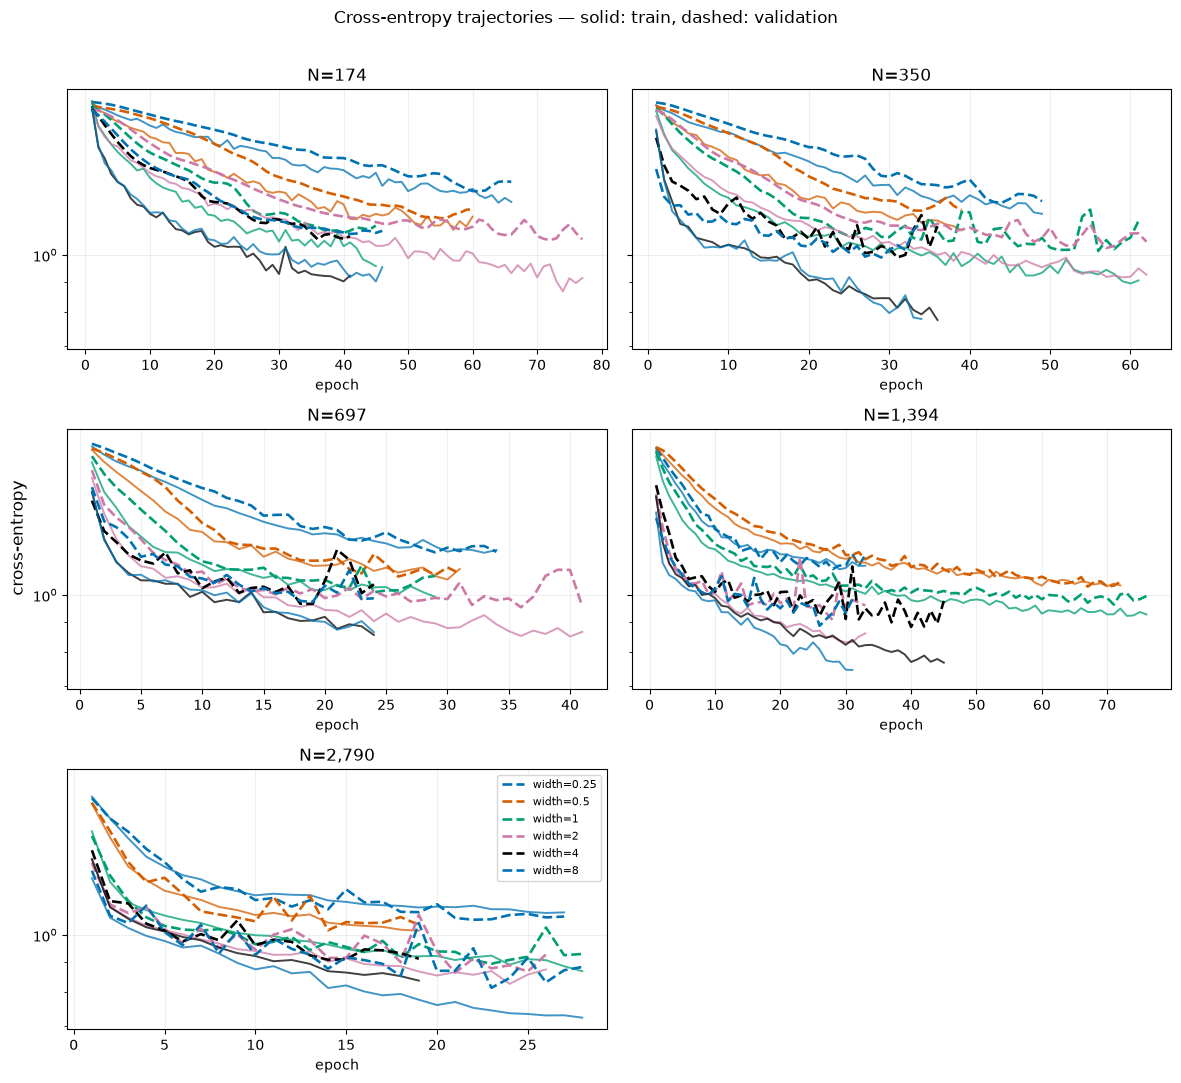

In [51]:
figure, axes_grid = plt.subplots(3, 2, figsize=(12, 11), sharey=True)
axes = axes_grid.ravel()
for axis, n_samples in zip(axes, n_values):
    group = selected_runs.loc[selected_runs["n_samples"] == n_samples].sort_values("width_multiplier")
    for _, run in group.iterrows():
        training_curve = decode_curve(run["training_loss_curve"])
        tune_curve = decode_curve(run["tune_loss_curve"])
        epochs = np.arange(1, len(training_curve) + 1)
        color = width_colors[run["width_multiplier"]]
        axis.plot(epochs, training_curve, color=color, alpha=0.75, linewidth=1.4)
        axis.plot(epochs, tune_curve, color=color, linestyle="--", linewidth=1.9, label=f"width={run['width_multiplier']:g}")
    axis.set(title=f"N={n_samples:,}", xlabel="epoch", yscale="log")
    axis.grid(alpha=0.2)
for axis in axes[len(n_values):]:
    axis.axis("off")
figure.supylabel("cross-entropy")
axes[len(n_values) - 1].legend(fontsize=8)
figure.suptitle("Cross-entropy trajectories — solid: train, dashed: validation")
figure.tight_layout(rect=(0, 0, 1, 0.97))

#### Interpretation

Increasing width generally lowers training cross-entropy, but validation benefit depends strongly on data volume and is not monotonic. At $N=174$, tune loss improves from 1.283 (width 0.25) to 1.060 (width 2), then worsens to 1.063 and 1.086 at widths 4 and 8. Width 2 is also best at $N=697$ (0.953), while width 4 is best at $N=1{,}394$ (0.883). At $N=350$, widths 4 and 8 are effectively tied (0.9904 versus 0.9901). Only at the full $N=2{,}790$ does width 8 provide a clear further gain, reaching 0.813 versus 0.863 at width 2 and 0.908 at width 4.

The jagged $N=2{,}790$ curves should be interpreted model by model rather than as a universal large-data instability. Widths 2 and 8 finish 0.064 and 0.069 above their respective validation minima, whereas width 4 finishes only 0.004 above its minimum. Across the complete 30-cell matrix, 11 selected runs show a post-optimum rise above 0.05. Early stopping restores the minimum-loss checkpoint, but the frequency of these excursions motivates the separate optimizer tuning below.

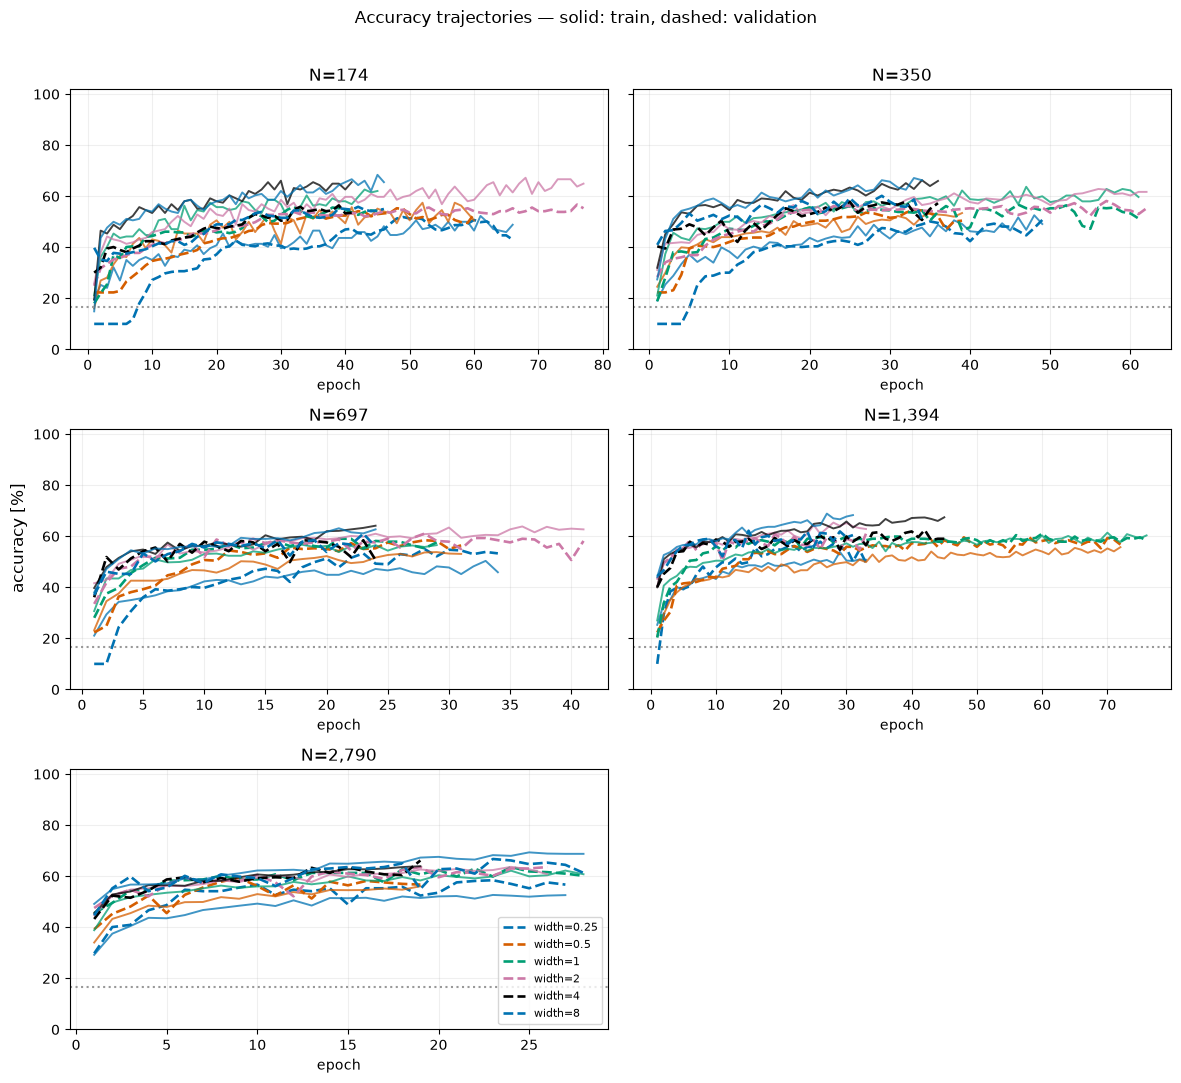

In [52]:
figure, axes_grid = plt.subplots(3, 2, figsize=(12, 11), sharey=True)
axes = axes_grid.ravel()
for axis, n_samples in zip(axes, n_values):
    group = selected_runs.loc[selected_runs["n_samples"] == n_samples].sort_values("width_multiplier")
    for _, run in group.iterrows():
        training_curve = 100 * decode_curve(run["training_accuracy_curve"])
        tune_curve = 100 * decode_curve(run["tune_accuracy_curve"])
        epochs = np.arange(1, len(training_curve) + 1)
        color = width_colors[run["width_multiplier"]]
        axis.plot(epochs, training_curve, color=color, alpha=0.75, linewidth=1.4)
        axis.plot(epochs, tune_curve, color=color, linestyle="--", linewidth=1.9, label=f"width={run['width_multiplier']:g}")
    axis.axhline(100 / len(preprocessor.class_names), color="0.6", linestyle=":")
    axis.set(title=f"N={n_samples:,}", xlabel="epoch", ylim=(0, 102))
    axis.grid(alpha=0.2)
for axis in axes[len(n_values):]:
    axis.axis("off")
figure.supylabel("accuracy [%]")
axes[len(n_values) - 1].legend(fontsize=8)
figure.suptitle("Accuracy trajectories — solid: train, dashed: validation")
figure.tight_layout(rect=(0, 0, 1, 0.97))

#### Interpretation

The best validation accuracies by data size are 55.0%, 60.2%, 59.0%, 61.9%, and 66.8%; the overall trend improves with $N$, although the single-seed values are not monotonic between $N=350$ and 697. At $N=174$, width 8 reaches no higher validation accuracy than widths 1 or 2 but opens an 11.9-percentage-point train–validation gap, a clear over-capacity pattern. At $N=2{,}790$, width 8 achieves the best accuracy with a much smaller 1.5-point gap, so the full dataset uses the added capacity more effectively.

### Update-normalized trajectories

These variants replace epoch number with the cumulative number of optimizer updates. For a run with $N$ samples and batch size $B$, epoch $e$ is plotted at $e \cdot \lceil N/B \rceil$ updates.

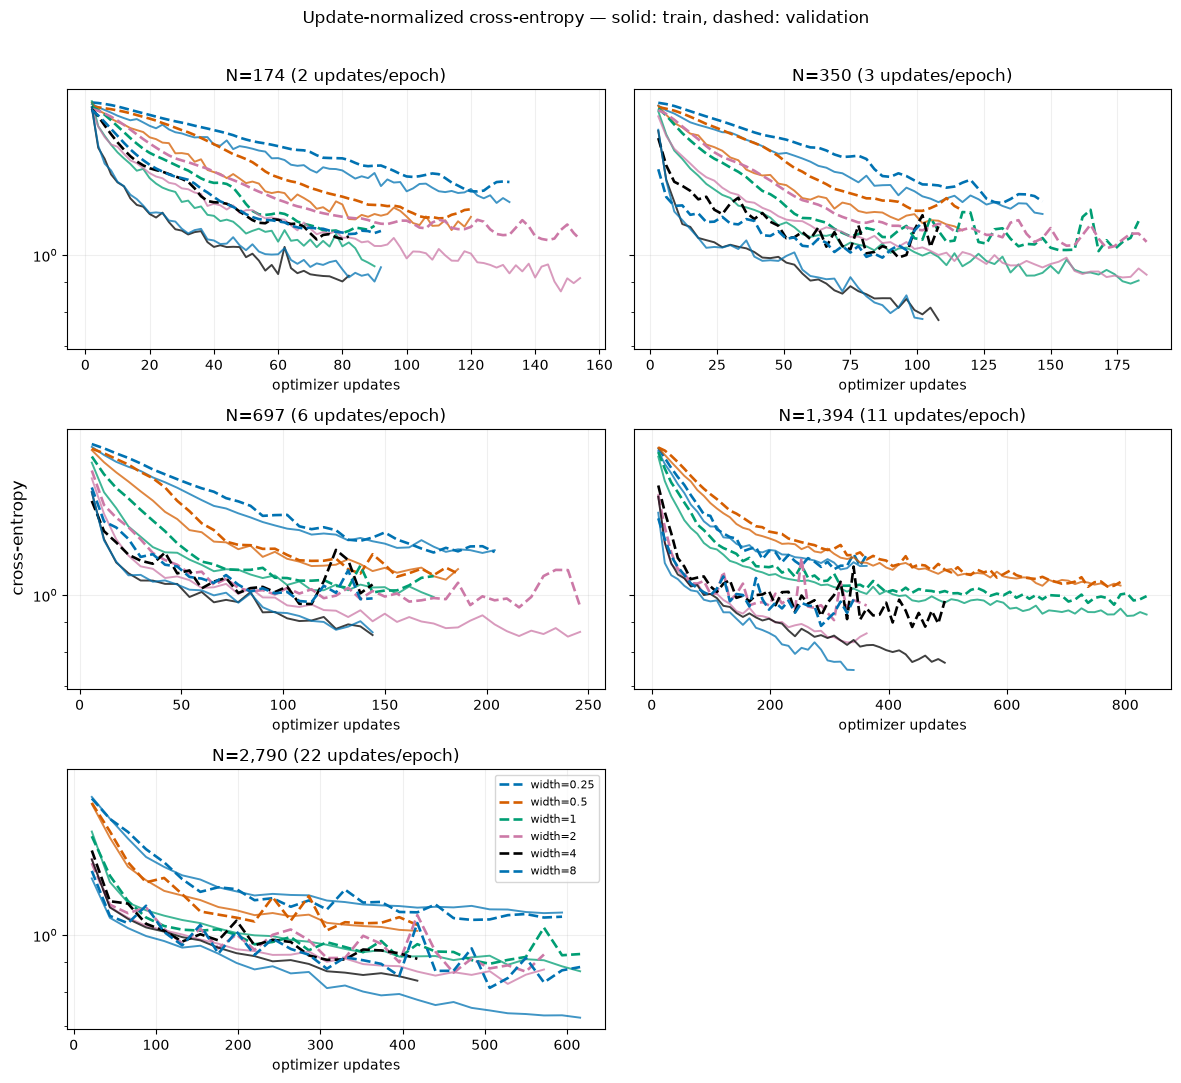

In [53]:
figure, axes_grid = plt.subplots(3, 2, figsize=(12, 11), sharey=True)
axes = axes_grid.ravel()
for axis, n_samples in zip(axes, n_values):
    group = selected_runs.loc[selected_runs["n_samples"] == n_samples].sort_values("width_multiplier")
    updates_per_epoch_values = np.ceil(group["n_samples"] / group["batch_size"]).astype(int).unique()
    if len(updates_per_epoch_values) != 1:
        raise ValueError(f"Inconsistent cached batch sizes for N={n_samples:,}.")
    updates_per_epoch = int(updates_per_epoch_values[0])
    for _, run in group.iterrows():
        training_curve = decode_curve(run["training_loss_curve"])
        tune_curve = decode_curve(run["tune_loss_curve"])
        updates = updates_per_epoch * np.arange(1, len(training_curve) + 1)
        color = width_colors[run["width_multiplier"]]
        axis.plot(updates, training_curve, color=color, alpha=0.75, linewidth=1.4)
        axis.plot(updates, tune_curve, color=color, linestyle="--", linewidth=1.9, label=f"width={run['width_multiplier']:g}")
    axis.set(title=f"N={n_samples:,} ({updates_per_epoch} updates/epoch)", xlabel="optimizer updates", yscale="log")
    axis.grid(alpha=0.2)
for axis in axes[len(n_values):]:
    axis.axis("off")
figure.supylabel("cross-entropy")
axes[len(n_values) - 1].legend(fontsize=8)
figure.suptitle("Update-normalized cross-entropy — solid: train, dashed: validation")
figure.tight_layout(rect=(0, 0, 1, 0.97))

#### Interpretation

The normalization exposes a 4.9-fold difference in optimization exposure. Median best-validation checkpoints occur at 96, 117, 150, 374, and 473 updates for increasing $N$. The three smallest datasets therefore overlap substantially in update space, whereas $N=1{,}394$ and 2,790 receive more optimization before their optima. The dense-looking epoch-to-epoch variation at $N=2{,}790$ is partly a sampling effect: adjacent plotted epochs are separated by 22 updates, compared with only 2 at $N=174$. The width-2 and width-8 post-optimum excursions remain visible after normalization and are configuration-specific.

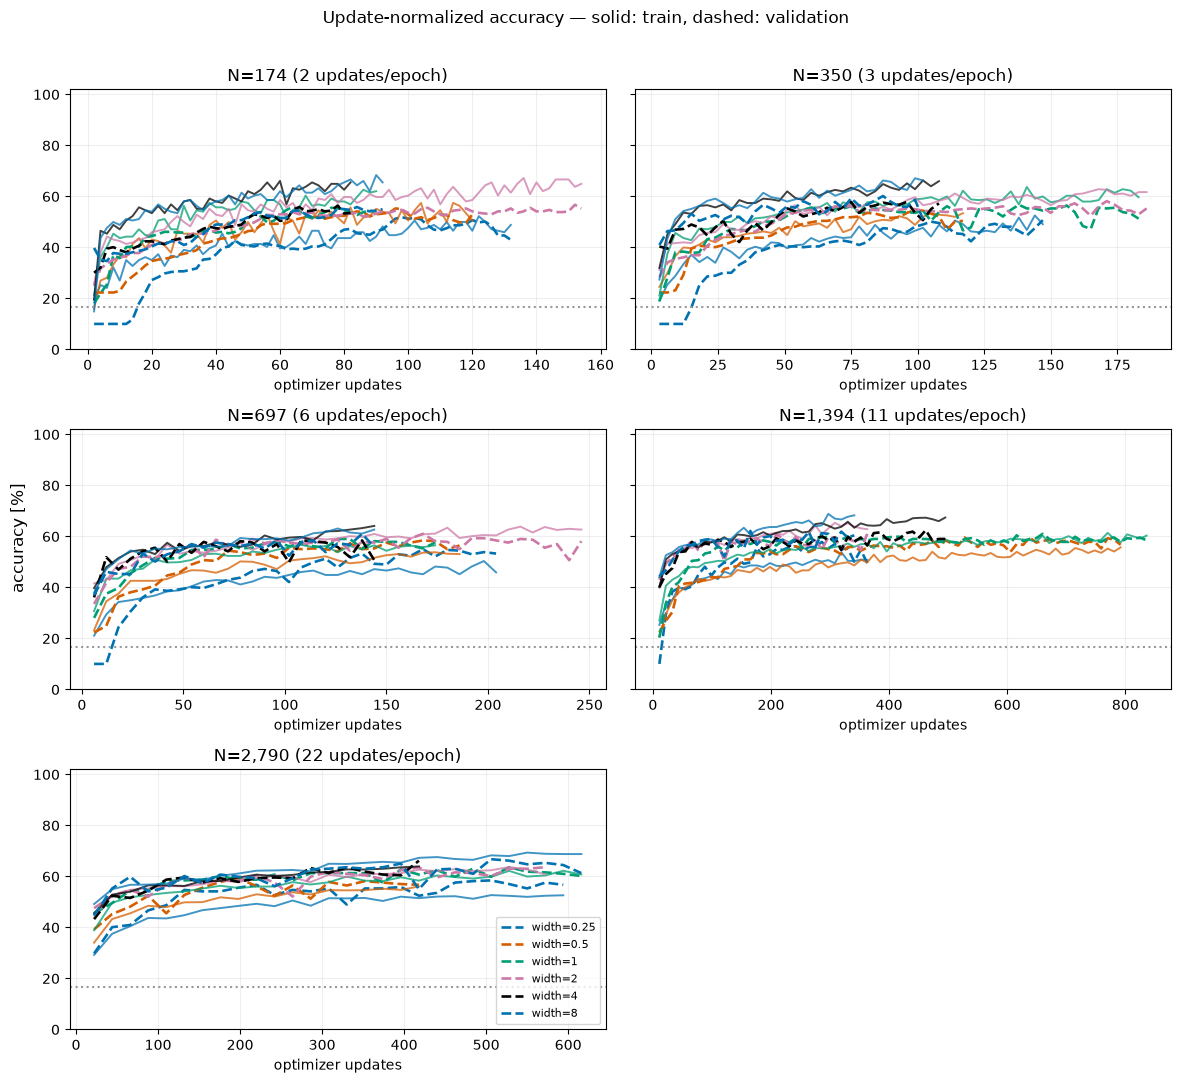

In [54]:
figure, axes_grid = plt.subplots(3, 2, figsize=(12, 11), sharey=True)
axes = axes_grid.ravel()
for axis, n_samples in zip(axes, n_values):
    group = selected_runs.loc[selected_runs["n_samples"] == n_samples].sort_values("width_multiplier")
    updates_per_epoch_values = np.ceil(group["n_samples"] / group["batch_size"]).astype(int).unique()
    if len(updates_per_epoch_values) != 1:
        raise ValueError(f"Inconsistent cached batch sizes for N={n_samples:,}.")
    updates_per_epoch = int(updates_per_epoch_values[0])
    for _, run in group.iterrows():
        training_curve = 100 * decode_curve(run["training_accuracy_curve"])
        tune_curve = 100 * decode_curve(run["tune_accuracy_curve"])
        updates = updates_per_epoch * np.arange(1, len(training_curve) + 1)
        color = width_colors[run["width_multiplier"]]
        axis.plot(updates, training_curve, color=color, alpha=0.75, linewidth=1.4)
        axis.plot(updates, tune_curve, color=color, linestyle="--", linewidth=1.9, label=f"width={run['width_multiplier']:g}")
    axis.axhline(100 / len(preprocessor.class_names), color="0.6", linestyle=":")
    axis.set(title=f"N={n_samples:,} ({updates_per_epoch} updates/epoch)", xlabel="optimizer updates", ylim=(0, 102))
    axis.grid(alpha=0.2)
for axis in axes[len(n_values):]:
    axis.axis("off")
figure.supylabel("accuracy [%]")
axes[len(n_values) - 1].legend(fontsize=8)
figure.suptitle("Update-normalized accuracy — solid: train, dashed: validation")
figure.tight_layout(rect=(0, 0, 1, 0.97))

#### Interpretation

The $N=174$, 350, and 697 runs reach their best checkpoints within 72–216 updates, yet their best validation accuracies remain at or below 60.2%. The $N=2{,}790$ runs reach their optima between 308 and 506 updates and attain up to 66.8%. The separation therefore reflects both more data and more optimization exposure; because the single-seed accuracy ordering is not perfectly monotonic, it should not be read as a precise learning law.

## 3. Scaling analysis

Cross-entropy is the primary scaling quantity because thresholded classification metrics can saturate while probabilistic fit still changes. Define the displayed generalization gap as $G=L_{\mathrm{tune}}-L_{\mathrm{train}}$. A large positive and widening $G$, together with falling train loss and flat or rising tune loss, is evidence of overfitting. A gap near zero is favorable only when the absolute tune loss is also low; if both losses are high, it instead indicates underfitting or unsuccessful optimization. Negative gaps can occur here because train loss is accumulated online while parameters change and dropout is active, whereas tune loss is evaluated afterward with dropout disabled, as well as through sampling variation. The gap is therefore a diagnostic to interpret jointly with tune loss and the full trajectories, not a standalone score.

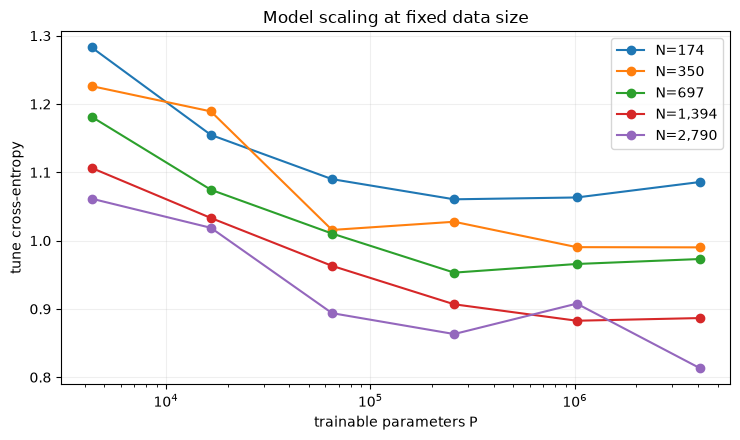

In [55]:
figure, axis = plt.subplots(figsize=(7.5, 4.5))
for n_samples, group in selected_runs.groupby("n_samples", sort=True):
    group = group.sort_values("parameter_count")
    axis.plot(group["parameter_count"], group["tune_loss"], marker="o", label=f"N={n_samples:,}")
axis.set_xscale("log")
axis.set(title="Model scaling at fixed data size", xlabel="trainable parameters P", ylabel="tune cross-entropy")
axis.grid(alpha=0.2)
axis.legend()
figure.tight_layout()

#### Interpretation

Data and capacity lower validation cross-entropy over parts of the measured grid, but the capacity curves are non-monotonic. Width 2 is optimal at $N=174$ and 697, width 4 at $N=1{,}394$, and widths 4 and 8 are effectively tied at $N=350$. At full data, width 8 recovers a clear advantage after the width-4 regression and attains the overall minimum of 0.813. The study therefore shows that four million parameters can be useful at $N=2{,}790$, not that validation loss decreases smoothly with every capacity step. Because every cell currently represents one model seed and a small learning-rate sweep, the apparent width-8 advantage requires optimizer tuning and seed confirmation before export.

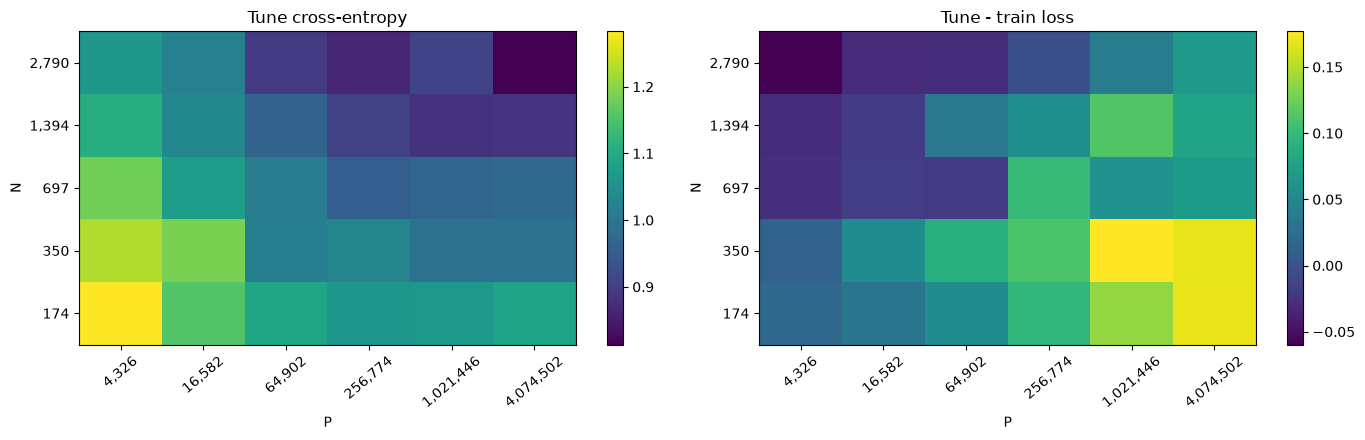

In [56]:
loss_matrix = selected_runs.pivot(index="n_samples", columns="parameter_count", values="tune_loss").sort_index().sort_index(axis=1)
gap = selected_runs.assign(loss_gap=selected_runs["tune_loss"] - selected_runs["training_loss"])
gap_matrix = gap.pivot(index="n_samples", columns="parameter_count", values="loss_gap").sort_index().sort_index(axis=1)

figure, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for axis, title, matrix in zip(axes, ("Tune cross-entropy", "Tune - train loss"), (loss_matrix, gap_matrix)):
    image = axis.imshow(matrix.to_numpy(), aspect="auto", origin="lower")
    axis.set(title=title, xlabel="P", ylabel="N", xticks=np.arange(len(matrix.columns)), yticks=np.arange(len(matrix.index)), xticklabels=[f"{v:,}" for v in matrix.columns], yticklabels=[f"{v:,}" for v in matrix.index])
    axis.tick_params(axis="x", labelrotation=40)
    figure.colorbar(image, ax=axis)
figure.tight_layout()

In [62]:
selected_runs.query('n_samples == 2790').sort_values(["tune_macro_f1"], ascending=False).head(5)

,n_samples,parameter_count,random_seed,training_loss,tune_loss,training_macro_f1,tune_macro_f1,best_epoch,epochs_run,batch_size,...,tune_loss_curve,training_accuracy_curve,tune_accuracy_curve,duration_seconds,peak_memory_bytes,failed,failure_reason,data_fraction,width_multiplier,learning_rate
29,2790,4074502,42,0.744783,0.813491,0.663015,0.675426,23,28,128,...,"[1.285544661874416, 1.078115240550656, 1.04774...","[0.4917562724014337, 0.5498207885304659, 0.567...","[0.4469914040114613, 0.5530085959885387, 0.598...",20.883933,531724288,False,NaN,1.0,8.0,0.0003
27,2790,256774,42,0.865058,0.863225,0.609129,0.632683,21,26,128,...,"[1.3253789924960424, 1.1263207525100272, 1.089...","[0.44731182795698926, 0.5243727598566308, 0.54...","[0.47564469914040114, 0.5243553008595988, 0.54...",3.239662,133033472,False,NaN,1.0,2.0,0.0010
26,2790,64902,42,0.922594,0.893827,0.568071,0.603853,23,28,128,...,"[1.4723428542429533, 1.2618663474960108, 1.142...","[0.3888888888888889, 0.4971326164874552, 0.518...","[0.45558739255014324, 0.49570200573065903, 0.5...",2.341584,74423296,False,NaN,1.0,1.0,0.0010
28,2790,1021446,42,0.868104,0.907771,0.600908,0.603417,14,19,128,...,"[1.3924710214308818, 1.1418227975211375, 1.131...","[0.4559139784946237, 0.5286738351254481, 0.540...","[0.4326647564469914, 0.5243553008595988, 0.515...",5.073046,256786432,False,NaN,1.0,4.0,0.0003
25,2790,16582,42,1.049325,1.018750,0.488471,0.512589,14,19,128,...,"[1.6768942678555376, 1.5006558355424329, 1.329...","[0.34050179211469533, 0.4329749103942652, 0.45...","[0.39255014326647564, 0.45272206303724927, 0.4...",1.772443,46533120,False,NaN,1.0,0.5,0.0010


#### Interpretation

The validation-loss heatmap ranges from 1.283 at $N=174$, $P=4{,}326$ to 0.813 at $N=2{,}790$, $P=4{,}074{,}502$. At $N=174$, the tune-minus-train gap grows from 0.020 to 0.169 with width while tune loss stops improving beyond width 2; that combination is the clearest small-data over-capacity signal. The matrix maximum is 0.177 at $N=350$, width 4. At $N=2{,}790$, gaps range from −0.060 to 0.069; the width-8 model has both the lowest absolute tune loss and the largest positive gap in that row. The gain is therefore real on the observed tune fold but not gap-free. Negative values for smaller widths do not mean that tune data are intrinsically easier: train loss is measured online with active dropout, whereas tune loss is measured afterward in evaluation mode.

## 4. Empirical scaling and compute efficiency

For each $N$, $P_\epsilon(N)$ is the smallest model within an absolute tune-loss tolerance of the best observed model. The fitted surface $L(N,P)=L_\infty + A N^{-\alpha} + B P^{-\beta}$ is descriptive for this dataset, not a claim of a universal scaling law.

,n_samples,best_tune_loss,loss_threshold,parameter_count,width_multiplier,selected_tune_loss
0,174,1.060493,1.080493,256774,2.0,1.060493
1,350,0.990145,1.010145,1021446,4.0,0.990449
2,697,0.953149,0.973149,256774,2.0,0.953149
3,1394,0.882724,0.902724,1021446,4.0,0.882724
4,2790,0.813491,0.833491,4074502,8.0,0.813491


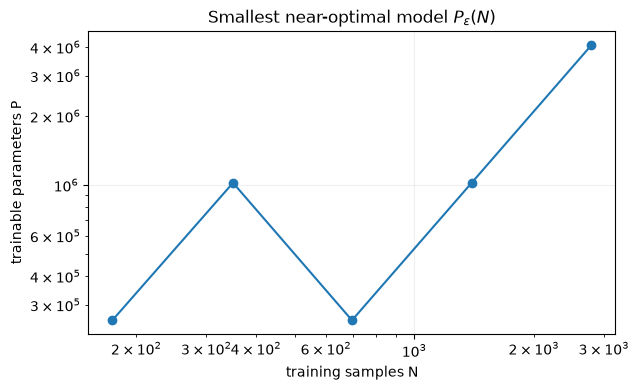

In [57]:
near_optimal = near_optimal_parameter_count(selected_runs, tolerance=0.02)
display(near_optimal)
figure, axis = plt.subplots(figsize=(6.5, 4))
axis.plot(near_optimal["n_samples"], near_optimal["parameter_count"], marker="o")
axis.set_xscale("log"); axis.set_yscale("log")
axis.set(title=r"Smallest near-optimal model $P_\epsilon(N)$", xlabel="training samples N", ylabel="trainable parameters P")
axis.grid(alpha=0.2)
figure.tight_layout()

#### Interpretation

With an absolute tolerance of 0.02 cross-entropy, the smallest near-optimal model has $P=256{,}774$ at $N=174$ and 697, and $P=1{,}021{,}446$ at $N=350$ and 1,394. Only at full $N=2{,}790$ is the four-million-parameter width-8 model required to remain within 0.02 of the observed optimum. Thus $P_\epsilon(N)$ generally increases with data size but is not monotonic in this single-seed grid; the optimizer-only confirmation below tests the boundary result that matters for export.

In [58]:
scaling_fit = fit_scaling_surface(selected_runs)
display(pd.Series(asdict(scaling_fit), name="descriptive scaling fit"))

irreducible_loss         5.317158e-10
data_coefficient         1.545378e+00
data_exponent            7.804838e-02
parameter_coefficient    8.118268e+00
parameter_exponent       4.164795e-01
Name: descriptive scaling fit, dtype: float64

#### Interpretation

The descriptive surface fit yields an estimated data exponent of 0.078 and capacity exponent of 0.416, with the irreducible-loss term collapsing numerically toward zero. This implausibly low asymptote, the non-monotonic capacity slices, and the best result at the upper $N$ and $P$ boundary show that the five-by-six grid does not identify a stable extrapolative scaling law. Within the observed range, the fit is only a compact association summary and does not estimate the optimal capacity beyond the measured grid.

,n_samples,parameter_count,learning_rate,tune_loss,duration_seconds,peak_memory_bytes
0,174,64902,0.0010,1.090026,0.672832,74422272
1,697,16582,0.0010,1.074476,0.808419,46533120
2,697,64902,0.0010,1.010389,0.813133,74423296
3,697,256774,0.0010,0.953149,1.577131,133033472
4,1394,256774,0.0010,0.906789,2.188341,133033472
5,2790,64902,0.0010,0.893827,2.341584,74423296
6,2790,256774,0.0010,0.863225,3.239662,133033472
7,2790,4074502,0.0003,0.813491,20.883933,531724288


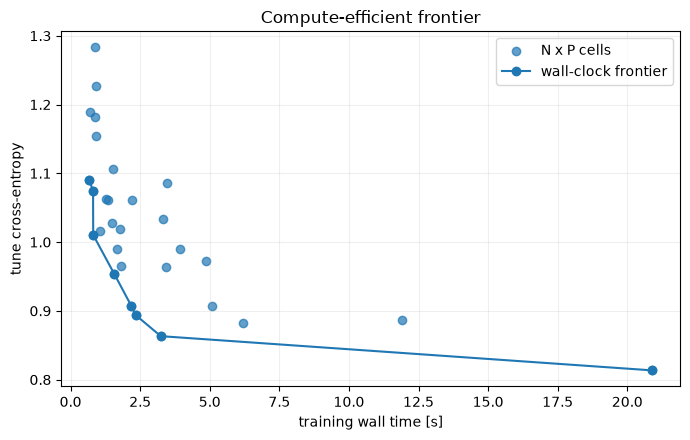

In [59]:
frontier = compute_efficiency_frontier(selected_runs)
display(frontier[["n_samples", "parameter_count", "learning_rate", "tune_loss", "duration_seconds", "peak_memory_bytes"]])

figure, axis = plt.subplots(figsize=(7, 4.5))
axis.scatter(selected_runs["duration_seconds"], selected_runs["tune_loss"], alpha=0.7, label="N x P cells")
axis.plot(frontier["duration_seconds"], frontier["tune_loss"], marker="o", label="wall-clock frontier")
axis.set(title="Compute-efficient frontier", xlabel="training wall time [s]", ylabel="tune cross-entropy")
axis.grid(alpha=0.2); axis.legend(); figure.tight_layout()

#### Interpretation

Eight of the 30 selected configurations form the observed wall-clock frontier. At $N=2{,}790$, moving from width 2 ($P=256{,}774$) to width 8 ($P=4{,}074{,}502$) lowers tune loss from 0.863 to 0.813, while wall time rises from 3.24 to 20.88 seconds and peak memory from 133 to 532 MB. The 0.050 loss reduction therefore costs about 6.4 times the training time and four times the peak memory. Width 2 is the clear compute-efficiency elbow; width 8 is the absolute single-seed optimum, while width 4 is dominated on both loss and runtime in this run.

## 5. Width-8 optimizer tuning and candidate export

The scaling grid identifies width 8 as the best full-data configuration, but only for one model seed and a three-value learning-rate sweep. This final stage freezes the complete width-8 architecture and tunes only the optimizer/training strategy with the same conditional search space, Optuna protocol and MLflow tracking used by the Extended-CNN workflow. Model capacity, kernels, dropout and the train/tune folds remain fixed. Tune macro-F1 is the optimization objective so that the exported candidate is aligned with Notebook 03; tune cross-entropy remains the early-stopping metric and a stability diagnostic. The test fold is never loaded.

In [64]:
WIDTH8_MODEL_CONFIG = {**BASE_MODEL_CONFIG, **scaled_cnn_config(8.0)}
OPTIMIZER_TUNING_ROOT = artifact_root() / "experiments" / "cnn_width8_optimizer"
OPTIMIZER_TUNING_ROOT.mkdir(parents=True, exist_ok=True)
OPTIMIZER_TRIALS = 25
OPTIMIZER_STORAGE = f"sqlite:///{OPTIMIZER_TUNING_ROOT / 'study.db'}"
OPTIMIZER_BASE_CONFIG = TrainingConfig(
    epochs=160, batch_size=256, learning_rate=5e-4, weight_decay=5e-4,
    scheduler_strategy="step", scheduler_step_size=15, learning_rate_decay=0.80,
    patience=25, report_every=20, random_seed=42,
    class_balance_strategy="weighted_loss", gradient_clip_norm=1.0,
)
optimizer_scan_config = OptunaScanConfig(
    scope="training", n_trials=OPTIMIZER_TRIALS, n_trials_mode="total",
    study_name="cnn-width8-optimizer-v1", storage=OPTIMIZER_STORAGE,
    sampler_seed=42, trial_seed=42, n_startup_trials=5,
    pruning_warmup_epochs=15,
)
optimizer_tracking = MLflowTrackingConfig.local(
    OPTIMIZER_TUNING_ROOT / "mlflow",
    experiment_name="timecourse-cnn-width8",
    parent_run_name="width8-optimizer-search",
)
display(pd.Series({
    "parameter_count": trainable_parameter_count(CNNClassifier(
        input_length=train_fold.features.shape[-1],
        num_classes=len(preprocessor.class_names), **WIDTH8_MODEL_CONFIG,
    )),
    "optimizer_trials": OPTIMIZER_TRIALS,
    "study_storage": OPTIMIZER_STORAGE,
}))

parameter_count                                               4074502
optimizer_trials                                                   25
study_storage       sqlite:////home/lorenz/Environments/Deeplearni...
dtype: object

In [65]:
optimizer_study = run_optuna_scan(
    model_type=CNNClassifier,
    base_model_config=WIDTH8_MODEL_CONFIG,
    base_training_config=OPTIMIZER_BASE_CONFIG,
    training_fold=train_fold, tuning_fold=tune_fold,
    preprocessor=preprocessor, device=device,
    scan_config=optimizer_scan_config,
    training_config_suggester=suggest_extended_cnn_training_config,
    mlflow_tracking=optimizer_tracking,
)
optimizer_trials = optimizer_study.trials_dataframe()
optimizer_trials.to_csv(OPTIMIZER_TUNING_ROOT / "trials.csv", index=False)
print("attempted trials:", len(optimizer_study.trials))
print("best tune macro-F1:", optimizer_study.best_value)

/home/lorenz/Environments/DeeplearningExamples/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-09-04 23:22:00,824] Using an existing study with name 'cnn-width8-optimizer-v1' instead of creating a new one.


attempted trials: 25
best tune macro-F1: 0.6992615727317338


In [66]:
best_optimizer_trial = optimizer_study.best_trial
best_optimizer_config = TrainingConfig(**best_optimizer_trial.user_attrs["training_config"])
optimizer_summary = pd.Series({
    "trial": best_optimizer_trial.number,
    "tune_macro_f1": best_optimizer_trial.value,
    "tune_loss": best_optimizer_trial.user_attrs["tune_loss"],
    "tune_accuracy": best_optimizer_trial.user_attrs["tune_accuracy"],
    "best_epoch": best_optimizer_trial.user_attrs["best_epoch"],
    **best_optimizer_trial.params,
}, name="best width-8 optimizer trial")
display(optimizer_summary)
display(optuna_parameter_importances(optimizer_study).to_frame())

trial                                         13
tune_macro_f1                           0.699262
tune_loss                               0.728891
tune_accuracy                           0.687679
best_epoch                                    72
training.learning_rate                  0.000148
training.use_weight_decay                   True
training.weight_decay                   0.000925
training.scheduler                          none
training.batch_size                           64
training.class_balance_strategy    weighted_loss
training.gradient_clip_norm                  5.0
Name: best width-8 optimizer trial, dtype: object

,importance
training.gradient_clip_norm,0.453725
training.learning_rate,0.232708
training.batch_size,0.125338
training.class_balance_strategy,0.107275
training.scheduler,0.053662
training.use_weight_decay,0.027292


#### Interpretation

Of 25 attempted trials, trial 13 provides the strongest restored tune macro-F1 (0.699) with tune loss 0.729. It uses learning rate $1.48 \times 10^{-4}$, weight decay $9.25 \times 10^{-4}$, batch size 64, no scheduler, weighted cross-entropy and gradient clipping at 5. The model remains fixed at 4,074,502 parameters throughout the search. Several trials reach macro-F1 around 0.694–0.696, so the optimum is not an isolated successful regime, but the single best trial remains subject to tune-selection optimism.

### Multi-seed confirmation

The best Optuna trial is a proposal selected on the tune fold, not yet a robust result. Its fixed model and training configuration are therefore repeated with three predetermined seeds. The confirmation mean and variation describe sensitivity to initialization; they do not turn the repeatedly used tune fold into an independent evaluation set.

In [67]:
optimizer_confirmation_results, optimizer_confirmation_runs = run_ablations(
    (AblationSpec(
        name="cnn_width8_optimizer",
        model_config=WIDTH8_MODEL_CONFIG,
        training_config=best_optimizer_config,
        random_seeds=(42, 43, 44),
    ),),
    model_type=CNNClassifier, training_fold=train_fold,
    tuning_fold=tune_fold, preprocessor=preprocessor, device=device,
)
optimizer_confirmation_summary = summarize_ablations(optimizer_confirmation_runs)
save_ablation_study(
    OPTIMIZER_TUNING_ROOT / "confirmation",
    results=optimizer_confirmation_results,
    frame=optimizer_confirmation_runs,
    summary=optimizer_confirmation_summary,
)
display(optimizer_confirmation_summary.round(4))

model_config: {'input_length': 289, 'num_classes': 6, 'channels': (256, 512, 1024), 'kernel_sizes': (9, 7, 5), 'dilations': (1, 1, 1), 'pool_size': 2, 'hidden_dim': 512, 'dropout': 0.2, 'residual': False}
trainable parameters: 4,074,502
training_config: TrainingConfig(epochs=160, batch_size=64, learning_rate=0.00014810670132106202, weight_decay=0.0009248210907965359, scheduler_step_size=15, learning_rate_decay=0.8, scheduler_strategy='none', warmup_epochs=0, warmup_start_factor=0.1, minimum_learning_rate=1e-06, patience=25, report_every=20, random_seed=42, class_balance_strategy='weighted_loss', gradient_clip_norm=5.0)
epoch   1: train loss 1.25782, validation loss 1.19794, train accuracy 43.5%, validation accuracy 42.1%
epoch  20: train loss 0.77431, validation loss 0.84548, train accuracy 65.6%, validation accuracy 61.0%
epoch  40: train loss 0.66499, validation loss 0.82755, train accuracy 70.8%, validation accuracy 66.2%
epoch  60: train loss 0.60195, validation loss 0.81127, train

,runs,failed_runs,tune_loss_mean,tune_loss_std,tune_accuracy_mean,tune_accuracy_std,tune_macro_f1_mean,tune_macro_f1_std,macro_f1_delta_mean,macro_f1_delta_std,macro_f1_gap_mean,best_epoch_mean,best_epoch_std,convergence_epoch_95_mean,post_best_degradation_mean,tune_loss_roughness_mean,duration_seconds_mean
name,,,,,,,,,,,,,,,,,
cnn_width8_optimizer,3,0,0.7276,0.0292,0.6705,0.0103,0.6764,0.01,NaN,NaN,0.0528,65.0,23.2594,54.6667,0.0903,0.0885,66.3637


#### Interpretation

Across seeds 42–44, the fixed optimizer configuration reaches tune macro-F1 $0.676 \pm 0.010$, tune loss $0.728 \pm 0.029$, and accuracy $67.1\% \pm 1.0\%$ (sample standard deviations). Relative to the original width-8 grid run, tune loss improves from 0.813 to 0.728 on average, while mean macro-F1 remains essentially unchanged (0.676 versus 0.675). The best Optuna trial's macro-F1 of 0.699 therefore should not be presented as a seed-robust improvement. The mean train-minus-tune macro-F1 gap is 0.053, so early stopping reduces but does not eliminate the overfitting signal. Because weighted training loss and unweighted tune loss are different objectives, their numerical loss difference is not used as a generalization estimate in this stage. Minor differences between repeated executions with the same nominal seed can remain on GPU unless deterministic algorithms are enforced; the saved checkpoint metrics below always describe the actual exported run.

### Reload-verified Notebook 03 candidate

After the configuration is frozen, seed 42 is retrained using exactly the confirmed model and optimizer settings. `fit_model` restores the minimum-tune-loss checkpoint before it is saved. The top-level artifact name begins with `cnn_`, making it discoverable by Notebook 03 after its registry filters for actual `model.pt` files. Only this frozen checkpoint, not an Optuna trial directory, becomes a family-comparison candidate.

In [68]:
CANDIDATE_NAME = "cnn_width8_optimizer"
CANDIDATE_SEED = 42
candidate_training_config = TrainingConfig(
    **{**best_optimizer_trial.user_attrs["training_config"], "random_seed": CANDIDATE_SEED}
)
candidate_model, candidate_parameter_count = create_model(
    CNNClassifier, input_length=train_fold.features.shape[-1],
    num_classes=len(preprocessor.class_names), random_seed=CANDIDATE_SEED,
    **WIDTH8_MODEL_CONFIG,
)
candidate_history = fit_model(
    candidate_model, candidate_training_config,
    training_fold=train_fold, tuning_fold=tune_fold, device=device,
)
candidate_model, candidate_paths = save_and_verify_experiment(
    CANDIDATE_NAME, candidate_model, candidate_history,
    preprocessor=preprocessor, training_fold=train_fold,
    tuning_fold=tune_fold, device=device,
)
candidate_best = candidate_history.best_epoch - 1
display(pd.Series({
    "experiment": CANDIDATE_NAME,
    "parameter_count": candidate_parameter_count,
    "best_epoch": candidate_history.best_epoch,
    "tune_loss": candidate_history.validation_loss[candidate_best],
    "tune_macro_f1": candidate_history.validation_macro_f1[candidate_best],
    "model_path": str(candidate_paths.model),
}, name="saved candidate"))

model_config: {'input_length': 289, 'num_classes': 6, 'channels': (256, 512, 1024), 'kernel_sizes': (9, 7, 5), 'dilations': (1, 1, 1), 'pool_size': 2, 'hidden_dim': 512, 'dropout': 0.2, 'residual': False}
trainable parameters: 4,074,502
training_config: TrainingConfig(epochs=160, batch_size=64, learning_rate=0.00014810670132106202, weight_decay=0.0009248210907965359, scheduler_step_size=15, learning_rate_decay=0.8, scheduler_strategy='none', warmup_epochs=0, warmup_start_factor=0.1, minimum_learning_rate=1e-06, patience=25, report_every=20, random_seed=42, class_balance_strategy='weighted_loss', gradient_clip_norm=5.0)
epoch   1: train loss 1.25773, validation loss 1.19750, train accuracy 43.5%, validation accuracy 41.8%
epoch  20: train loss 0.77246, validation loss 0.83632, train accuracy 65.3%, validation accuracy 61.3%
epoch  40: train loss 0.66791, validation loss 0.83580, train accuracy 71.1%, validation accuracy 65.3%
epoch  60: train loss 0.60437, validation loss 0.80845, train

experiment                                      cnn_width8_optimizer
parameter_count                                              4074502
best_epoch                                                        72
tune_loss                                                   0.733558
tune_macro_f1                                               0.697185
model_path         /home/lorenz/Environments/DeeplearningExamples...
Name: saved candidate, dtype: object

#### Export result

The reload-verified `cnn_width8_optimizer` artifact contains the 4,074,502-parameter CNN restored at epoch 72. Its saved seed-42 run reaches tune loss 0.734 and tune macro-F1 0.697. These values refer to the actual exported checkpoint and can differ slightly from another seed-42 execution because the GPU training path is not configured for strict deterministic replay. This single checkpoint is the candidate consumed by Notebook 03; the three-seed mean above is the more appropriate estimate of configuration stability.

## Conclusions

The memorization experiment confirms that the CNN and optimizer can fit the task: 32 examples reach 100% training accuracy and near-zero training loss. Its validation optimum occurs at epoch 13 and deteriorates sharply thereafter, demonstrating that optimization capacity alone is not evidence of generalization.

Across the full scaling matrix, additional data generally improves held-out performance, while useful capacity depends on $N$. The best single-seed validation accuracy rises from 55.0% at $N=174$ to 66.8% at $N=2{,}790$, and the best cross-entropy falls from 1.060 to 0.813. At $N=174$, widths above 2 add train–tune separation without improving tune loss. At full data, width 8 instead achieves the best observed loss and accuracy, although its positive loss gap of 0.069 means that the gain is not gap-free.

The visibly jagged trajectories must be interpreted at the configuration level. Each plotted epoch at $N=2{,}790$ aggregates 22 optimizer updates, compared with 2 at $N=174$, and 11 of the 30 selected cells show a post-optimum loss rise above 0.05. Early stopping restores the minimum-loss checkpoint, while the optimizer-only search explicitly addresses the remaining optimization sensitivity of width 8.

The scaling grid uses a constant learning rate with `patience=5`; all 30 selected runs stop between epochs 19 and 77. The median completed exposure rises from 106 updates at $N=174$ to 583 at $N=2{,}790$, so epoch-normalized comparisons mix data scale with optimization exposure. The final width-8 tuning stage instead searches the same training-strategy space used for Extended CNNs and confirms its best proposal across three seeds.

Within the raw grid, width 2 is the compute-efficiency elbow and width 8 is the absolute full-data optimum: its 0.050 lower tune loss costs about 6.4 times the wall time and four times the peak memory. Across the three confirmation seeds, optimizer tuning lowers mean width-8 tune loss to $0.728 \pm 0.029$, while tune macro-F1 is $0.676 \pm 0.010$ and therefore essentially matches the original grid run's 0.675. The reload-verified seed-42 checkpoint saved as `cnn_width8_optimizer` reaches tune loss 0.734 and macro-F1 0.697 and is the candidate for Notebook 03. These results establish a measured candidate and performance frontier, not a universal scaling law or proof against overfitting. The test fold remains untouched, so every result in this notebook describes validation performance only.